# Intervention B — ColdLLM-Style Synthetic Interaction Generation for Cold-Start Items

**Intervention B** uses an LLM as a behaviour simulator to manufacture interactions for strict
cold-start items, following the two-stage funnel from ColdLLM (arXiv:2402.09176) —
**Filtering Simulation** narrows every cold item's candidate pool from all 384,339 users down to
the top-K most content-similar, then **Refining Simulation** asks an LLM about each surviving
(item, user) pair. The survivors become synthetic interactions, added to `ref_train` before
fitting ALS — giving a cold item something to learn from *before* it has accumulated a single
real interaction, which is exactly the case `steel_thread.ipynb` shows ALS's own fold-in cannot
help with at all (`recalculate_item`'s closed-form solve returns the exact zero vector at k=0).

That synthetic-augmented ALS fit is then wrapped in **CBHCF**, using the same field weights and
the same lambda as the baseline, so the comparison isolates the synthetic interactions'
contribution rather than conflating it with an architecture difference.

### Scores, then selection — the central design decision

The paper's refiner is LoRA-tuned, so its yes/no verdict carries a calibrated confidence. Run
**zero-shot**, the same question is answered "yes" for ~98% of the candidates Filtering has
*already* selected (measured, `bench_24`). A binary verdict is therefore nearly constant: it
discards the ordering *within* those yes-es, which is the only informative part of the output,
and leaves a probability threshold with nothing to sort.

So Refining stores a **graded log-odds per pair** and every decision about which pairs become
interactions happens afterwards, offline:

| arm | rule | question it answers |
|---|---|---|
| **B1 / B2** | top-N users per item by score | does the LLM's *ordering* help? |
| **+ calibrated** | same, minus each user's own baseline | is it ranking users or their agreeableness? |
| **random-N** | N users drawn at random from the same pool | **is there any signal at all?** |
| **popularity-N** | the N most active users in the pool | is the LLM just a popularity proxy? |

Ranking rather than thresholding because the *ordering* is the trustworthy part of an
uncalibrated judge — any monotone recalibration leaves top-N unchanged while moving a cutoff
arbitrarily. Fixing the **count** also keeps the arms comparable: ALS's fold-in is directly
sensitive to how many rows sit behind a cold item, so if one arm injected 49 interactions per
item and another 25, a difference between their curves would confound volume with quality.

**`random-N` is the arm that decides whether Intervention B did anything.** Top-N always
produces exactly N interactions per item, so the synthetic matrix looks healthy even if the
ordering is pure noise — the 98%-yes symptom is now hidden by construction. If the LLM arms do
not beat random-N, content similarity did the work and the LLM is decorative.

### How this notebook is meant to be run

Refining is ~136,000 LLM calls **per strategy** and runs for hours, so it is structured as
**plan → launch → assemble**. Open `intervention_b_worker.ipynb` to run a second worker on the
other GPU; it claims chunks from the same manifest. Either notebook can be started late,
interrupted, or never run at all. Because every chunk's scores land on disk as they finish,
**restarting the kernel between §5 and §6 costs nothing** — which matters, because vLLM holds
most of the card and the evaluation half wants it back.

## 0. Environment & imports

In [1]:
%%time
import gc
import hashlib
import json
import os
import pickle
import platform
import sys
import time

# PIN THIS NOTEBOOK TO ONE PHYSICAL CARD, before anything can initialise CUDA. vLLM selects its
# GPU from CUDA_VISIBLE_DEVICES and offers no per-engine device argument, so the choice has to be
# made process-wide and made first. Everything downstream then addresses that card as "cuda:0",
# whichever physical card it is -- so DEVICE below is NOT a typo, and changing PHYSICAL_GPU is the
# only edit needed to move this notebook to the other card.
#
# GPU 1 by default: GPU 0 drives the desktop and may be wanted for other things.
# intervention_b_worker.ipynb is the same idea pinned to GPU 0, for when it is free.
PHYSICAL_GPU = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = PHYSICAL_GPU

sys.path.insert(0, "..")  # notebook lives in notebooks/; the recsys/ package is one level up

import numpy as np
import scipy.sparse as sparse
import matplotlib
try:
    get_ipython()            # defined only under IPython/Jupyter -> keep the inline backend
except NameError:
    matplotlib.use("Agg")    # plain `python script.py`: headless, save figures to PNG instead
import matplotlib.pyplot as plt
import implicit
import wandb

from recsys import load
from recsys import cf
from recsys import cbhcf
from recsys import content
from recsys import coldllm
from recsys import eval as ev

DEVICE = "cuda:0"            # the pinned card after the remap, whichever physical card it is
CONTENT_CACHE_GPU = DEVICE   # build the Mode A content block with cuSPARSE SpMM (18x vs CPU)

print(f"python     {platform.python_version()}  ({platform.machine()})")
print(f"implicit   {implicit.__version__}")
print(f"pinned to physical GPU {PHYSICAL_GPU}, addressed as {DEVICE}")

WANDB_ENTITY_NAME = "mads-team-cold-start"
WANDB_PROJECT_NAME = "llm-cold-start-recsys"
RUN_TAG = time.strftime("%Y%m%d-%H%M%S")
WANDB_ENABLED = False  # flip to True to upload runs to W&B (off by default; disabled = no-op)
WANDB_MODE = "online" if WANDB_ENABLED else "disabled"

/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of '/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/implicit/gpu/_cuda.so: undefined symbol: _ZN3rmm13device_bufferC1EmNS_16cuda_stream_viewENS_6detail23cccl_async_resource_refIN4cuda2mr3__412resource_refIJNS6_17device_accessibleEEEEEE'
  warnings.warn(


python     3.12.13  (x86_64)
implicit   0.7.3
pinned to physical GPU 1, addressed as cuda:0
CPU times: user 3.06 s, sys: 588 ms, total: 3.65 s
Wall time: 2.75 s


## 1. Load the same dataset/split as the steel thread

Identical `DATA_PATH`/`SPLIT_PARAMS`/`cache_pickle` pattern as `steel_thread.ipynb` — same
dataset fingerprint `FP`, so the two notebooks' cached artifacts (the Dataset itself, the
content matrix, the CBHCF content block) are **shared, not duplicated**.

In [2]:
%%time
# Identical cache_pickle helper to steel_thread.ipynb -- see that notebook's Section 0 markdown
# for the fingerprinting rationale (keyed on inputs for the Dataset itself, on outputs for
# everything downstream). Duplicated here rather than imported so this notebook stays runnable on
# its own; keep the two definitions in sync if either changes.
def cache_pickle(name, compute, params=None):
    tag = "" if params is None else "_" + hashlib.md5(repr(params).encode()).hexdigest()[:8]
    path = f"../data/cache/{name}{tag}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    val = compute()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(val, f, protocol=pickle.HIGHEST_PROTOCOL)
    return val


DATA_PATH = "../data/filtered/books_5core_common.parquet"
META_PATH = "../data/filtered/books_meta_5core_common.parquet"
SPLIT_PARAMS = dict(cold_item_fraction=0.10, cold_val_fraction=0.10)

dataset = cache_pickle("books_dataset", lambda: load.load_dataset(data_path=DATA_PATH, **SPLIT_PARAMS),
                       params=load.load_params_fingerprint(DATA_PATH, **SPLIT_PARAMS))
FP = load.dataset_fingerprint(dataset)   # every downstream cache key includes this

N_REVEAL = 20
K_LEVELS = list(range(N_REVEAL + 1))
K = 100
N_SEEDS = 10     # matches steel_thread.ipynb -- the band has to be comparable to the baseline's
METRICS = ev.METRICS  # ["NDCG", "Precision", "Recall", "HitRate", "AUC"]

print(f"users: {dataset.n_users:,}   items: {dataset.n_items:,}")
print(f"cold items (test): {len(dataset.cold_item_ids):,}")
print(f"ref_train non-zeros: {dataset.ref_train.nnz:,}   ref_test non-zeros: {dataset.ref_test.nnz:,}")
print(f"reserved cold-item test interactions: {dataset.test_matrix.nnz:,}")
print(f"dataset fingerprint: {FP}")

<timed exec>:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.


users: 384,339   items: 487,790
cold items (test): 2,727
ref_train non-zeros: 2,676,601   ref_test non-zeros: 345,998
reserved cold-item test interactions: 13,635
dataset fingerprint: (384339, 487790, 2676601, 345998, 347561, 2727, 633483902, 13635, 2727, 625156242)
CPU times: user 47.6 ms, sys: 191 ms, total: 239 ms
Wall time: 241 ms


## 2. Baseline — CBHCF with no synthetic interactions, computed here

Intervention B is only interesting relative to the *best* baseline, so this compares against
**CBHCF**, not Popularity or plain ALS.

That curve is computed **in this notebook**, in §7, as a `"none"` arm — an all-zeros synthetic
matrix pushed through the identical `curve_for_arm` path as every real arm. It is not loaded
from `steel_thread.ipynb`'s `baseline_cf_*.pkl` any more, for two reasons:

- **Comparability.** A saved curve comes from different code, possibly a different `N_SEEDS`,
  and a separately-built content block. The means were comparable; the *bands* were not, and
  the old code had to print a caveat saying so. Same seeds, same content block, same sweep —
  now the spread means the same thing on both sides, which is what §8's paired tests need.
- **Run order.** It removes the only thing that made this notebook depend on a prior steel
  thread run. Each notebook now runs once, in order, and `steel_thread.ipynb` reads *this*
  notebook's export rather than the two of them needing each other.

`ref_train + 0 == ref_train`, so the `"none"` arm is plain ALS wrapped in plain CBHCF — the
baseline by construction, not by convention.

## 3. Item content — the same TF-IDF space, plus plain text for the prompts

- **`item_content`** — the row-L2-normalized BM25F matrix, feeding Filtering (§4) and the CBHCF
  wrap (§6). Field weights come from `../outputs/hyperparams.json["steel_thread_config"]`, so
  this is keyed identically to `steel_thread.ipynb`'s and **loads that notebook's matrix**.
- **`item_metadata`** — one plain string per item, feeding the Refining prompt.

**Which roles go in the prompt is a cost decision, and a large one.** Measured with the real
tokenizer over 300 sampled pairs: `title+creator+taxonomy+blurb` averages **1,506 tokens** per
prompt; adding the `reviews` role — which maps to Amazon's `description` column, 847 words on
its own — takes it to **9,434**. That 6.3× lands almost entirely on the ten history items, and
is the difference between a long day and a long week of GPU time. `item_content` is untouched by
this: Filtering and CBHCF still use all five roles at the tuned weights.

In [3]:
%%time
def load_steel_config():
    path = "../outputs/hyperparams.json"
    if not os.path.exists(path):
        raise FileNotFoundError(f"No {path} -- run intervention_a_weight_sweep.ipynb first.")
    with open(path) as f:
        rec = json.load(f).get("steel_thread_config")
    if rec is None:
        raise KeyError(f"{path} has no steel_thread_config; run intervention_a_weight_sweep.ipynb.")
    if tuple(rec["dataset_fingerprint"]) != FP:
        raise RuntimeError(
            f"{path} steel_thread_config was tuned on a different split -- refusing to use it. "
            f"artifact {tuple(rec['dataset_fingerprint'])}, current {FP}.")
    return rec


STEEL_CFG = load_steel_config()
CBHCF_FIELD_WEIGHTS = STEEL_CFG["cbhcf"]["field_weights"]
CBHCF_LAMBDA = float(STEEL_CFG["cbhcf"]["content_weight"])
print(f"CBHCF lambda={CBHCF_LAMBDA}  field_weights={CBHCF_FIELD_WEIGHTS}")

warm_item_ids = np.unique(dataset.ref_train.nonzero()[1])
_docs = {}


def docs():
    if "d" not in _docs:
        _docs["d"] = content.load_item_documents(META_PATH, dataset,
                                                 field_map=content.BOOKS_FIELD_MAP)
    return _docs["d"]


# Keyed EXACTLY as steel_thread.ipynb keys it, weights included -- that is what makes this a load
# rather than a 4-minute rebuild, and what stops it silently returning a matrix built under
# different weights.
item_content = cache_pickle(
    "books_content_tfidf",
    lambda: content.fit_content_space(docs(), warm_item_ids, weights=CBHCF_FIELD_WEIGHTS,
                                      min_df=2).transform(docs()),
    params=(FP, "bm25f", "warmfit", "mindf2", repr(CBHCF_FIELD_WEIGHTS)))
print(f"item x term content matrix: {item_content.shape[0]:,} x {item_content.shape[1]:,}   "
      f"nnz {item_content.nnz:,}")

# The prompt text. PROMPT_ROLES is part of the run key, so changing it starts a clean run instead
# of blending scores generated under two different prompts.
PROMPT_ROLES = ("title", "creator", "taxonomy", "blurb")
MAX_HISTORY = 10   # history items per prompt; ColdLLM's own setting, and the dominant token cost

item_metadata = cache_pickle(
    "coldllm_item_metadata",
    lambda: [" ".join(filter(None, (docs()[r][i] for r in PROMPT_ROLES)))
             for i in range(dataset.n_items)],
    params=(FP, PROMPT_ROLES))
n_empty_cold = sum(1 for i in dataset.cold_item_ids if not item_metadata[i].strip())
print(f"item_metadata ({'+'.join(PROMPT_ROLES)}): {len(item_metadata):,} items, "
      f"{n_empty_cold:,} cold items with no text at all")

CBHCF lambda=3.0  field_weights={'title': 1.0, 'creator': 1.0, 'taxonomy': 0.5, 'blurb': 1.0, 'reviews': 1.0}


<timed exec>:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.


item x term content matrix: 487,790 x 490,444   nnz 135,923,048
item_metadata (title+creator+taxonomy+blurb): 487,790 items, 0 cold items with no text at all
CPU times: user 326 ms, sys: 2.01 s, total: 2.34 s
Wall time: 2.36 s


## 4. Filtering Simulation (TF-IDF content similarity)

Stage 1 uses no LLM: `user_content_profile` builds each user's content profile the same way
CBHCF's own frozen user profile is built, then `filter_candidates` ranks users per cold item by
inner product against it. Both sides are L2-normalized, so the inner product **is** cosine
similarity. Filtering's output is independent of the prompting strategy, so it runs **once** and
every arm below consumes it — including the controls, which is what makes them fair.

In [4]:
%%time
COLDLLM_TOP_K = 50   # Stage 1: candidate users kept per cold item

# Set to an integer for a smoke run; None runs the full cold-item population. A subsampled run is
# NOT comparable to the baseline curve -- §6 narrows test_matrix to match, so the two cover
# different item sets. Use it to prove the pipeline works, not to draw a conclusion.
SUBSAMPLE_N_COLD = None

if SUBSAMPLE_N_COLD is None:
    coldllm_cold_items = np.asarray(dataset.cold_item_ids)
else:
    _rng = np.random.default_rng(0)
    coldllm_cold_items = np.sort(_rng.choice(dataset.cold_item_ids,
                                             size=min(SUBSAMPLE_N_COLD, len(dataset.cold_item_ids)),
                                             replace=False))
    print(f"*** SMOKE RUN: {len(coldllm_cold_items)} of {len(dataset.cold_item_ids):,} cold items. "
          f"Not comparable to the baseline curve. ***")

user_profiles = cache_pickle("coldllm_user_profiles",
                             lambda: coldllm.user_content_profile(dataset.ref_train, item_content),
                             params=(FP, repr(CBHCF_FIELD_WEIGHTS)))
candidates = cache_pickle(
    "coldllm_candidates",
    lambda: coldllm.filter_candidates(item_content, user_profiles, coldllm_cold_items,
                                      top_k=COLDLLM_TOP_K),
    params=(FP, repr(CBHCF_FIELD_WEIGHTS), COLDLLM_TOP_K, len(coldllm_cold_items),
            int(coldllm_cold_items.sum())))
n_pairs = sum(len(v) for v in candidates.values())
candidate_users = np.unique(np.concatenate([np.asarray(v) for v in candidates.values()]))
print(f"candidates: {len(candidates):,} cold items x up to {COLDLLM_TOP_K} users "
      f"= {n_pairs:,} pairs per strategy")
print(f"distinct candidate users: {len(candidate_users):,} "
      f"({len(candidate_users) / n_pairs:.1%} of pairs -- this is what the §5f calibration pass costs)")

candidates: 2,727 cold items x up to 50 users = 136,350 pairs per strategy
distinct candidate users: 78,717 (57.7% of pairs -- this is what the §5f calibration pass costs)
CPU times: user 16.3 ms, sys: 5.62 s, total: 5.63 s
Wall time: 5.67 s


## 5. Refining Simulation — plan, launch, assemble

The one stage that differs between **B1 (direct)** and **B2 (reasoning)**. Both keep structured
decoding, now for a second reason beyond parseability: it guarantees that *both* "yes" and "no"
appear among the returned logprobs at the answer position, so the log-odds is always defined.
Without the constraint a confident model pushes the losing answer out of the top-k.

**The work directory must live on a real POSIX filesystem.** Claiming is an atomic
`O_CREAT | O_EXCL` create and staleness is read off the file's mtime; both hold on ext4, which is
where `../data/` sits under WSL. Do not point `WORK_ROOT` at `/mnt/...`.

In [5]:
%%time
COLDLLM_MODEL = "Qwen/Qwen2.5-7B-Instruct-AWQ"
# 4-bit AWQ: ~5.5 GB of weights instead of ~15.2 GB for bf16, which leaves far more of the 24 GB
# card for KV cache -- and KV cache is what prefix caching spends, which is what makes this run
# affordable. A binary relevance judgment is not a task where 4-bit quantization is expected to
# cost much. Alternatives: "meta-llama/Llama-3.1-8B-Instruct" (vLLM's best-tested architecture),
# "microsoft/Phi-3.5-mini-instruct" (~3.8B, cheaper still). "Qwen/Qwen3-14B" does NOT fit in bf16.
CHUNK_SIZE = 64           # cold items per claimable unit of work
BATCH_SIZE = 256          # prompts queued per .chat() call
N_PROBE = coldllm.DEFAULT_N_PROBE   # probe items per user for the §5f calibration pass

STRATEGIES = ["direct", "reasoning"]   # B1, B2 -- see recsys/coldllm.py's `reasoning` flag
PROMPT_TAG = f"{'+'.join(PROMPT_ROLES)}|hist{MAX_HISTORY}"

# One engine per pass, reused across all its chunks -- engine startup is a minute or two, so
# building one per chunk would dominate the run.
ENGINE_KWARGS = dict(
    gpu_memory_utilization=0.90,
    # Sized from the EXACT distribution over all 136,350 pairs, not a sample. Measured: p50 746,
    # p90 1,623, p99.9 5,120, max 9,889 tokens. An earlier 8,192 was set from 300 sampled prompts
    # (max 4,506) and 5 pairs -- 0.0037% -- exceeded it, which aborts the whole 3,200-prompt chunk
    # they land in. 300 samples cannot see a 1-in-100,000 tail. 16,384 clears the true maximum by
    # 66% and is well inside the model's native 32,768.
    #
    # Raising this does NOT change any score: a prompt that already fitted produces the identical
    # output, so results computed under the old value stay valid and are not recomputed.
    max_model_len=16384,
    enable_prefix_caching=True,  # the whole reason run_worker orders its prompts by user
)

WORK_ROOT = "../data/coldllm"
RUN_KEYS = {s: coldllm.run_key(FP, COLDLLM_MODEL, COLDLLM_TOP_K, s, PROMPT_TAG, "pairs")
            for s in STRATEGIES}
WORK_DIRS = {s: os.path.join(WORK_ROOT, RUN_KEYS[s]) for s in STRATEGIES}


def _meta(strategy, unit, extra=None):
    """Everything a second worker needs to reproduce these prompts EXACTLY, so the two notebooks
    cannot drift into generating different prompts under the same run key."""
    m = {"strategy": strategy, "unit": unit, "model": COLDLLM_MODEL, "prompt_tag": PROMPT_TAG,
         "top_k": COLDLLM_TOP_K, "prompt_roles": list(PROMPT_ROLES), "max_history": MAX_HISTORY,
         "batch_size": BATCH_SIZE, "field_weights": CBHCF_FIELD_WEIGHTS,
         "engine_kwargs": ENGINE_KWARGS}
    m.update(extra or {})
    return m


manifests = {s: coldllm.plan_work(candidates, WORK_DIRS[s], chunk_size=CHUNK_SIZE,
                                  meta=_meta(s, "item"))
             for s in STRATEGIES}
for s in STRATEGIES:
    p = coldllm.progress(WORK_DIRS[s], manifests[s])
    print(f"[{s:<9}] {WORK_DIRS[s]}   {len(manifests[s]['chunks'])} chunks, "
          f"{manifests[s]['n_pairs']:,} pairs   done {p['done']}  todo {p['todo']}")

[direct   ] ../data/coldllm/f0977cacc395   43 chunks, 136,350 pairs   done 43  todo 0
[reasoning] ../data/coldllm/b5af90252628   43 chunks, 136,350 pairs   done 43  todo 0
CPU times: user 2.06 ms, sys: 412 μs, total: 2.47 ms
Wall time: 2.41 ms


### 5b. The per-user calibration pass

Each user is scored against a small, **shared** sample of real items to estimate their own
baseline agreeableness, which §6 subtracts. This is the only calibration that can change a
per-item ranking: a global or per-item correction is constant within one item's 50 candidates
and provably cannot reorder them (`bench_25`), but *users* vary within that ranking — someone
with a long, generic, bestseller-heavy history plausibly draws a high score for almost any book.
Subtracting their own mean converts "which users are agreeable" into "which users are agreeable
**about this book**". Structurally this is PMI — cancel a marginal to recover an association —
in logit space rather than log space because these probabilities saturate near 1.

The probe items are real books rather than a content-free placeholder: an empty or "N/A" item is
out of distribution, so probing with it would measure the model's reaction to a degenerate
prompt instead of the user's baseline. Averaging over several is an honest Monte Carlo estimate
of `E_i[score(u, i)]`. The **same** probe set is used for every user, which makes it a paired
design and removes probe-set variance from exactly the comparison that matters.

**Mind the cost model here — it is priced per user, while the main pass is priced per pair.**
Filtering produced 136,350 pairs but only ~79k *distinct* users (57.7%), and each needs
`N_PROBE` prompts, so at `N_PROBE=8` this pass issues ~4.6× as many prompts as the thing it
corrects. What keeps that affordable is that every probe for a user shares that
user's entire history prefix — differing only in the trailing item — so prefix caching serves
most of each additional probe. In *token* terms the pass costs roughly 1.4× the main one rather
than 4.6×, but that depends on prefix caching actually delivering, which §5f checks against real
numbers.

`CALIBRATE_STRATEGIES` defaults to `direct` only. B2's probes would need reasoning-length
completions, and B2's log-odds live on a different scale anyway (conditioned on its own generated
text), so a prior measured under one prompt style cannot be subtracted from the other.

In [6]:
%%time
CALIBRATE_STRATEGIES = ["direct"]     # see the note above on why not both

PROBE_ITEMS = coldllm.probe_items(item_metadata, warm_item_ids, n_probe=N_PROBE, seed=0)
prior_candidates = {int(u): PROBE_ITEMS for u in candidate_users}

PRIOR_KEYS = {s: coldllm.run_key(FP, COLDLLM_MODEL, COLDLLM_TOP_K, s,
                                 f"{PROMPT_TAG}|probe{N_PROBE}", "userprior")
              for s in CALIBRATE_STRATEGIES}
PRIOR_DIRS = {s: os.path.join(WORK_ROOT, PRIOR_KEYS[s]) for s in CALIBRATE_STRATEGIES}
# Small chunks (users, not items) so a PARTIAL prior pass is still informative: §5f reads whatever
# has finished and reports what the correction is doing, which is what decides whether the rest of
# this pass is worth paying for.
prior_manifests = {
    s: coldllm.plan_work(prior_candidates, PRIOR_DIRS[s], chunk_size=512,
                         meta=_meta(s, "user", {"probe_items": [int(i) for i in PROBE_ITEMS],
                                                "n_probe": int(N_PROBE)}))
    for s in CALIBRATE_STRATEGIES}
print(f"probe items: {list(PROBE_ITEMS)}")
print(f"  e.g. {item_metadata[int(PROBE_ITEMS[0])][:120]}")
for s in CALIBRATE_STRATEGIES:
    p = coldllm.progress(PRIOR_DIRS[s], prior_manifests[s])
    print(f"[{s:<9}] prior pass: {len(prior_manifests[s]['chunks'])} chunks, "
          f"{prior_manifests[s]['n_pairs']:,} prompts "
          f"({prior_manifests[s]['n_pairs'] / n_pairs:.1f}x the main pass in PROMPTS; far less in "
          f"tokens if prefix caching holds)   done {p['done']}  todo {p['todo']}")

probe items: [np.int32(7422), np.int32(16966), np.int32(33528), np.int32(117137), np.int32(135155), np.int32(233206), np.int32(289121), np.int32(399076)]
  e.g. Masters and Commanders: How Four Titans Won the War in the West, 1941-1945 Andrew Roberts Books|Biographies & Memoirs|Le
[direct   ] prior pass: 154 chunks, 629,736 prompts (4.6x the main pass in PROMPTS; far less in tokens if prefix caching holds)   done 154  todo 0
CPU times: user 88.9 ms, sys: 5.76 ms, total: 94.7 ms
Wall time: 94.3 ms


### 5c. Launch the workers — **one pass per cell**

Each pass is its own cell so it can be started, stopped, and judged independently. Measured at
~14.9 prompts/s (3,200-prompt chunks in ~3.6 min):

| cell | prompts | one GPU |
|---|---|---|
| 5c-i  B1 pairs | 136,350 | ~2.6 h |
| 5c-ii B2 pairs | 136,350 | ~3.0 h (longer completions) |
| 5c-iii user priors | 629,736 | ~3–12 h — **sample it first** |

**Interrupting any of these is safe.** The chunk in flight is lost; every finished chunk is on
disk, and the abandoned claim is reclaimed once its heartbeat goes stale. Re-running resumes.
To use both cards, run `intervention_b_worker.ipynb` on the other one — it can join at any time.

In [7]:
def _launch(strategy, work_dir, manifest, cands, max_chunks=None):
    return coldllm.run_worker(work_dir, manifest, cands, item_metadata, dataset.ref_train,
                              model=COLDLLM_MODEL, reasoning=(strategy == "reasoning"),
                              unit=manifest["meta"]["unit"], batch_size=BATCH_SIZE,
                              max_history=MAX_HISTORY, engine_kwargs=ENGINE_KWARGS,
                              max_chunks=max_chunks)

#### 5c-i. B1 `direct` — pair scoring

In [8]:
%%time
_launch("direct", WORK_DIRS["direct"], manifests["direct"], candidates)

[pid1358-1786296785] nothing to do -- all 43 chunks complete
CPU times: user 1.9 ms, sys: 0 ns, total: 1.9 ms
Wall time: 1.42 ms


[]

#### 5c-ii. B2 `reasoning` — pair scoring

In [9]:
%%time
_launch("reasoning", WORK_DIRS["reasoning"], manifests["reasoning"], candidates)

[pid1358-1786296785] nothing to do -- all 43 chunks complete
CPU times: user 1.57 ms, sys: 0 ns, total: 1.57 ms
Wall time: 1.21 ms


[]

#### 5c-iii. Per-user priors — **sample before committing**

This pass is priced per user, not per pair, and is the most expensive of the three at face value.
`PRIOR_SAMPLE_CHUNKS` stops it early so §5f can be read against real data: run this, look at
§5e/§5f, and only then decide whether to finish. Unclaimed chunks are untouched by stopping, so
finishing is just setting `PRIOR_SAMPLE_CHUNKS = None` and re-running this cell.

The first chunk's printed rate settles the 3–12 h range on its own: these prompts share ~93% of
their tokens with each other, so if prefix caching delivers it will run far faster than the pair
passes did.

In [10]:
%%time
PRIOR_SAMPLE_CHUNKS = None   # None = run to completion; an int stops early to sample it first

for s in CALIBRATE_STRATEGIES:
    _launch(s, PRIOR_DIRS[s], prior_manifests[s], prior_candidates,
            max_chunks=PRIOR_SAMPLE_CHUNKS)

[pid1358-1786296785] nothing to do -- all 154 chunks complete
CPU times: user 2.42 ms, sys: 0 ns, total: 2.42 ms
Wall time: 1.89 ms


#### 5c-iv. Finish anything still outstanding

A backstop for unattended runs. The cells above each drive one pass, so running them out of
order — or interrupting one — can leave a pass short while execution moves on, and §5e assembles
the pair scores with `strict=True` and would raise hours later. This keeps claiming from every
manifest until all of them report `todo = 0`, so reaching §5e means the work really is complete.

It also covers the case where the other GPU's worker dies overnight: its abandoned claims go
stale and are reclaimed here rather than stranding those chunks.

In [11]:
%%time
_ALL_PASSES = ([(s, WORK_DIRS[s], manifests[s]) for s in STRATEGIES]
               + [(s, PRIOR_DIRS[s], prior_manifests[s]) for s in CALIBRATE_STRATEGIES])

for _round in range(20):
    left = [(s, d, m) for s, d, m in _ALL_PASSES if coldllm.progress(d, m)["todo"] > 0]
    if not left:
        print(f"all passes complete after {_round} round(s)")
        break
    for s, work_dir, man in left:
        p = coldllm.progress(work_dir, man)
        print(f"\n>>> {man['meta']['strategy']}/{man['meta']['unit']}: {p['todo']} chunk(s) "
              f"outstanding", flush=True)
        cands = candidates if man["meta"]["unit"] == "item" else prior_candidates
        _launch(s, work_dir, man, cands)
else:
    print("WARNING: still incomplete after 20 rounds -- check for chunks failing repeatedly")

for s, d, m in _ALL_PASSES:
    p = coldllm.progress(d, m)
    print(f"[{m['meta']['strategy']:<9} {m['meta']['unit']:<4}] {p['done']}/{p['total']} done, "
          f"{p['todo']} todo")

all passes complete after 0 round(s)
[direct    item] 43/43 done, 0 todo
[reasoning item] 43/43 done, 0 todo
[direct    user] 154/154 done, 0 todo
CPU times: user 0 ns, sys: 2.6 ms, total: 2.6 ms
Wall time: 2.19 ms


### 5d. Progress

Safe to re-run at any time, including while a worker is going in the other notebook.

In [12]:
for label, work_dir, man in ([("pairs", WORK_DIRS[s], manifests[s]) for s in STRATEGIES]
                             + [("prior", PRIOR_DIRS[s], prior_manifests[s])
                                for s in CALIBRATE_STRATEGIES]):
    p = coldllm.progress(work_dir, man)
    print(f"[{man['meta']['strategy']:<9} {label}] {p['done']:>4}/{p['total']:<4} chunks "
          f"({100.0 * p['done'] / max(p['total'], 1):5.1f}%)   "
          f"in flight {p['in_flight']}   todo {p['todo']}")

[direct    pairs]   43/43   chunks (100.0%)   in flight 0   todo 0
[reasoning pairs]   43/43   chunks (100.0%)   in flight 0   todo 0
[direct    prior]  154/154  chunks (100.0%)   in flight 0   todo 0


### 5e. Assemble the scores

`strict=True` refuses to assemble a partial run: a matrix missing chunks would understate the
intervention and read as a weak result rather than an incomplete one.

In [13]:
%%time
pair_scores, user_priors, refine_stats = {}, {}, {}
for s in STRATEGIES:
    # The main pass is strict: a partial set of pairs would understate the intervention.
    u, i, sc, st = coldllm.assemble_scores(WORK_DIRS[s], manifests[s])
    pair_scores[s], refine_stats[s] = (u, i, sc), st
    print(f"[{s:<9}] {st['n_scored']:,} pairs scored   log-odds p10 {st['logodds_p10']:+.2f}  "
          f"p50 {st['logodds_p50']:+.2f}  p90 {st['logodds_p90']:+.2f}   "
          f"({st['frac_yes']:.1%} would be 'yes' under a hard verdict)")
    if st["n_unscored"]:
        print(f"           WARNING {st['n_unscored']:,} pairs had no readable yes/no logprob")

# The prior pass is NOT strict -- a partial one is still worth reading, because §5f uses it to
# decide whether finishing it is worth the GPU time. But a partial prior must never build a
# calibrated ARM: select_top_n would score uncovered users as if their baseline were 0, silently
# mixing calibrated and raw scores within one item's ranking.
PRIOR_COVERAGE, PRIOR_STATS = {}, {}
for s in CALIBRATE_STRATEGIES:
    priors, pst = coldllm.assemble_user_priors(PRIOR_DIRS[s], prior_manifests[s], strict=False)
    user_priors[s], PRIOR_STATS[s] = priors, pst
    PRIOR_COVERAGE[s] = len(priors) / max(len(candidate_users), 1)
    pv = np.array(list(priors.values())) if priors else np.zeros(0)
    print(f"[{s:<9}] prior: {len(priors):,}/{len(candidate_users):,} users "
          f"({PRIOR_COVERAGE[s]:.1%})"
          + (f"   mean {pv.mean():+.2f}  sd {pv.std():.2f}" if pv.size else "")
          + ("" if PRIOR_COVERAGE[s] >= 1.0 else
             "   <-- PARTIAL: read §5f, then finish the pass before trusting a calibrated arm"))

[direct   ] 136,350 pairs scored   log-odds p10 +6.76  p50 +13.43  p90 +15.10   (97.1% would be 'yes' under a hard verdict)
[reasoning] 136,350 pairs scored   log-odds p10 -2.35  p50 +16.98  p90 +22.14   (88.3% would be 'yes' under a hard verdict)
[direct   ] prior: 78,717/78,717 users (100.0%)   mean +1.94  sd 3.72
CPU times: user 1.06 s, sys: 104 ms, total: 1.16 s
Wall time: 1.27 s


### 5f. Is the per-user prior worth finishing?

**Run this on a partial prior pass and read it before paying for the rest.** Three things have
to hold for the correction to be worth having, and they can all be checked early:

1. **Is there a between-user signal to remove?** `var_between_users` — how much users genuinely
   differ in blanket agreeableness.
2. **Is `N_PROBE` large enough to measure it?** The prior is a sample mean carrying error
   `σ_within/√n`, and that error is subtracted from every score. If the prior is too noisy the
   correction *adds* more noise than the bias it removes. The break-even is
   `n > var_within / var_between`, reported as `n_probe_required`; `N_PROBE` must clear it, with
   margin. If it does not, raising `N_PROBE` is the fix — lowering it makes things worse.
3. **Does it actually reorder?** The decisive check, and not implied by the first two: variance
   can be large and still not change a within-item ranking, which is the only ordering that
   matters here.

In [14]:
for s in CALIBRATE_STRATEGIES:
    st = PRIOR_STATS[s]
    req = st["n_probe_required"]
    print(f"[{s:<9}] var within-user {st['var_within_user']:.3f}   "
          f"between-user {st['var_between_users']:.3f}   "
          f"(observed across prior means {st['var_of_prior_means']:.3f})")
    print(f"           N_PROBE = {N_PROBE}, break-even needs > {req:.1f}   "
          + ("OK -- the prior is estimated well enough to help"
             if N_PROBE > req else
             "TOO NOISY -- subtracting this prior would inject more noise than bias it removes; "
             "raise N_PROBE or drop the calibrated arm"))

for s in CALIBRATE_STRATEGIES:
    u, i, sc = pair_scores[s]
    base = np.array([user_priors[s].get(int(x), np.nan) for x in u])
    both = np.isfinite(sc) & np.isfinite(base)
    if both.sum() < 100:
        print(f"[{s}] only {both.sum()} covered pairs -- run more of the prior pass first.")
        continue
    total_var, between = float(np.var(sc[both])), float(np.var(base[both]))
    print(f"[{s:<9}] covered pairs {both.sum():,}/{len(sc):,} ({both.mean():.1%})")
    print(f"           var(score) {total_var:.3f}   var(user baseline) {between:.3f}   "
          f"between-user share {between / max(total_var, 1e-12):.1%}")
    print(f"           corr(score, baseline) {np.corrcoef(sc[both], base[both])[0, 1]:+.3f}")

    # What it does to the actual selection, restricted to items whose candidates are FULLY covered
    # -- a partly covered item would compare a calibrated ranking against a half-calibrated one.
    covered_items = np.unique(i[both])
    full = np.isin(i, covered_items) & ~np.isin(i, np.unique(i[~both]))
    if full.sum() > 0:
        raw = coldllm.select_top_n(u[full], i[full], sc[full], 7, dataset.n_users, dataset.n_items)
        cal = coldllm.select_top_n(u[full], i[full], sc[full], 7, dataset.n_users,
                                   dataset.n_items, priors=user_priors[s])
        a, b = set(zip(*raw.nonzero())), set(zip(*cal.nonzero()))
        n_items_full = len(np.unique(i[full]))
        print(f"           at N=7 over {n_items_full:,} fully covered items: Jaccard "
              f"{len(a & b) / max(len(a | b), 1):.3f}  "
              f"({len(a - b):,} of {len(a):,} selections change)")
        print("           -> near 1.000 means the prior changes nothing; finish the pass only if "
              "this is meaningfully below 1")

[direct   ] var within-user 17.920   between-user 11.583   (observed across prior means 13.823)
           N_PROBE = 8, break-even needs > 1.5   OK -- the prior is estimated well enough to help
[direct   ] covered pairs 136,350/136,350 (100.0%)
           var(score) 16.295   var(user baseline) 12.759   between-user share 78.3%
           corr(score, baseline) +0.172
           at N=7 over 2,727 fully covered items: Jaccard 0.161  (13,791 of 19,089 selections change)
           -> near 1.000 means the prior changes nothing; finish the pass only if this is meaningfully below 1


### 5g. Release the GPU before evaluating

vLLM holds ~90% of the card and §6 needs it back. If the memory does not come back, **restart
the kernel and re-run from the top, skipping §5c** — every score is already on disk, so that
costs a few minutes of cached loads. That property is the whole point of the work queue.

In [15]:
def release_gpu(min_free_gb=10.0, tries=3):
    """Reclaim the card from vLLM, and VERIFY it came back.

    `del`-ing the LLM object is not sufficient on its own: vLLM runs its engine as a spawned
    CHILD PROCESS, and a child can outlive the object that owns it -- observed today, holding
    23.8 GB after its parent had exited. In an unattended run that surfaces hours later as an
    inexplicable OOM in section 7, so any engine child of THIS kernel is terminated explicitly and
    the result is checked rather than assumed.
    """
    import signal
    import subprocess
    import torch

    for attempt in range(tries):
        gc.collect()
        torch.cuda.empty_cache()
        free, total = torch.cuda.mem_get_info(0)
        if free / 2**30 >= min_free_gb:
            print(f"cuda:0  {free / 2**30:.1f} GB free of {total / 2**30:.1f} GB -- ready")
            return True
        # Still short: look for engine children of this kernel and end them.
        me = os.getpid()
        try:
            ps = subprocess.run(["ps", "-eo", "pid,ppid,cmd"], capture_output=True, text=True).stdout
        except Exception:
            ps = ""
        killed = []
        for line in ps.splitlines():
            parts = line.split(None, 2)
            if len(parts) == 3 and parts[1] == str(me) and "VLLM::EngineCore" in parts[2]:
                try:
                    os.kill(int(parts[0]), signal.SIGKILL)
                    killed.append(parts[0])
                except Exception:
                    pass
        print(f"  attempt {attempt + 1}: {free / 2**30:.1f} GB free"
              + (f", terminated engine child {killed}" if killed else ", no engine child found"))
        time.sleep(8)

    free, total = torch.cuda.mem_get_info(0)
    print(f"WARNING cuda:0 only {free / 2**30:.1f} GB free of {total / 2**30:.1f} GB. Section 7 "
          f"needs roughly {min_free_gb:.0f} GB for the content block; if it fails, restart the "
          f"kernel and re-run -- every score is on disk, so nothing is recomputed.")
    return False


release_gpu()

cuda:0  22.4 GB free of 24.0 GB -- ready


True

## 6. Selection — building the arms

**`N` is fixed a priori, not tuned here.** Everywhere else in this project a hyperparameter is
selected on the cold *validation* population; that is not available for `N` without scoring
`cold_val` with the LLM as well, which would double the GPU cost. Rather than quietly select
`N` on the test cold set — which would bias every number below — it is fixed in advance by a
rule that refers to no result at all: **give a cold item the interaction count of a typical
warm item**, i.e. the median degree in `ref_train`.

That anchor matters more than it might look. The median warm item has ~7 training interactions
and only ~2% have 50, so selecting the whole `top_k=50` pool would make every cold item resemble
a top-2% bestseller — and ALS's fold-in would pull its factor toward that crowd's centroid.
`N` is a bias–variance knob: too few and the cold factor is noisy, too many and it blurs toward
popularity. Matching the median puts it where a real item sits.

§8 reports the sensitivity curve across `N` as a **robustness check, not a selection** — read it
as "does the conclusion survive other N", never as "which N is best". It also provides a free
correctness check: at `N = COLDLLM_TOP_K` every arm keeps the whole candidate pool, so all six
arms must collapse onto the same matrix and the LLM-vs-random gap must be exactly zero.

`top_k` itself is the one knob that cannot be revisited offline: it decides which pairs were
ever scored, so raising it means re-running the LLM. Lowering it is free, which is why erring
high (50) was the safe direction.

In [16]:
%%time
# A priori rule, evaluated on the TRAINING matrix only -- no cold-item outcome is consulted.
_item_degree = np.diff(sparse.csc_matrix(dataset.ref_train).indptr)
_warm_degree = _item_degree[_item_degree > 0]
N_SELECT = int(np.median(_warm_degree))
print(f"warm item degree: median {np.median(_warm_degree):.0f}  mean {_warm_degree.mean():.1f}  "
      f"p90 {np.percentile(_warm_degree, 90):.0f}   ({(_warm_degree >= COLDLLM_TOP_K).mean():.1%} "
      f"of warm items reach top_k={COLDLLM_TOP_K})")
print(f"N = {N_SELECT} synthetic interactions per cold item "
      f"(= the median warm item; a priori, NOT tuned on any result)")


# --- can top-N abstain, and does it need to? -----------------------------------------------------
# MUST come before ARM_ORDER, which reads INCLUDE_FLOOR_ARM. (It previously sat after it, so the
# cell raised NameError -- and the notebook checker missed it because it gathers every name defined
# anywhere in a cell before checking use, so it cannot see ordering WITHIN a cell.)
#
# Top-N ignores the SIGN of the score: an item whose 50 candidates were all rejected still receives
# its N least-rejected users. That is the one thing this rule cannot express -- "no plausible
# audience" -- and it is not harmless. With no synthetic data, fold-in returns the exact zero
# vector at k=0 and CBHCF ranks the item on content alone; injecting N wrong users instead makes
# the collaborative half contribute NOISE, which can land the item below where content alone would
# have put it.
#
# The rule is stated BEFORE the numbers are seen and consults no cold-item outcome: if more than
# 5% of items are being forced past what the model endorsed, the abstention variant is a live
# question and gets its own arm; otherwise it is a footnote.
FLOOR_ARM_THRESHOLD = 0.05
_forced = {}
for s in STRATEGIES:
    u, i, sc = pair_scores[s]
    order = np.argsort(i, kind="stable")
    i_s, sc_s = i[order], sc[order]
    bounds = np.flatnonzero(np.diff(i_s)) + 1
    n_pos = np.array([np.sum(np.nan_to_num(g, nan=-np.inf) > 0) for g in np.split(sc_s, bounds)])
    _forced[s] = float((n_pos < N_SELECT).mean())
    print(f"[{s:<9}] positive-scoring candidates per item: median {np.median(n_pos):.0f} of "
          f"{COLDLLM_TOP_K}   items with fewer than N={N_SELECT}: "
          f"{(n_pos < N_SELECT).sum():,} ({_forced[s]:.1%})   "
          f"with none at all: {(n_pos == 0).sum():,} ({(n_pos == 0).mean():.1%})")

INCLUDE_FLOOR_ARM = max(_forced.values()) > FLOOR_ARM_THRESHOLD
print(f"\n{'ADDING' if INCLUDE_FLOOR_ARM else 'skipping'} the abstention arms "
      f"(threshold {FLOOR_ARM_THRESHOLD:.0%}, observed {max(_forced.values()):.1%})")

# --- priors: impute the population MEAN for users the pass could not score -----------------------
# Requiring 100% coverage was unsatisfiable in practice -- a handful of users have no readable
# yes/no logprob on any probe, so the calibrated arm would be discarded after the entire prior pass
# had been paid for (observed: 99.5% coverage, arm skipped). Missing users instead take the mean of
# the priors that WERE measured. `select_top_n` would otherwise default them to 0.0, which on a
# scale centred near +13 is a wild outlier that would push those users to the top of every item
# they appear in; the mean keeps every user on one scale and bounds the error by the priors' spread.
PRIOR_MIN_COVERAGE = 0.98
user_priors_filled, CALIBRATED_OK = {}, []
for s in CALIBRATE_STRATEGIES:
    cov = PRIOR_COVERAGE.get(s, 0.0)
    if cov < PRIOR_MIN_COVERAGE:
        print(f"SKIPPING the {s}_cal arm: prior covers {cov:.1%} of candidate users "
              f"(< {PRIOR_MIN_COVERAGE:.0%}). Finish that pass (§5c) to include it.")
        continue
    have = user_priors[s]
    mean_prior = float(np.mean(list(have.values())))
    user_priors_filled[s] = {int(u): have.get(int(u), mean_prior) for u in candidate_users}
    CALIBRATED_OK.append(s)
    print(f"{s}_cal INCLUDED: {cov:.2%} measured, "
          f"{len(candidate_users) - len(have):,} users imputed at the mean ({mean_prior:+.2f})")


_ARMS_MEMO = {}


def build_arms(n_select, seed=0):
    """The matrices compared at a given N. Every arm draws from the SAME candidate pool, and every
    arm is matched in volume to the control it is judged against -- only the choice of which users
    differs.

    Memoized because it is called once per (arm, seed) in three separate sections plus the
    N-sensitivity grid -- several hundred times over a full run -- and each call re-runs
    `select_top_n` over all 136,350 scored pairs for every arm. The matrices are ~19k nonzeros
    each, so holding them all costs almost nothing.
    """
    _memo_key = (n_select, seed)
    if _memo_key in _ARMS_MEMO:
        return _ARMS_MEMO[_memo_key]
    # The BASELINE arm: no synthetic interactions at all. Kept out of ARM_ORDER because it is not
    # a competitor -- it is what every arm is measured against. Running it through the same
    # `curve_for_arm` path as everything else is the point: `ref_train + 0 == ref_train`, so this
    # fits plain ALS and wraps plain CBHCF, but it does so with THIS notebook's seeds, content
    # block and sweep code. The curve used to be read out of the steel thread's saved run, which
    # meant comparing against a number produced by different code on a possibly different seed
    # count -- hence the old "the means stay comparable; the bands do not" caveat. Computed here,
    # the bands are comparable too, and the notebook no longer needs baseline_cf_*.pkl to exist.
    arms = {"none": sparse.csr_matrix((dataset.n_users, dataset.n_items), dtype=np.float32)}
    for s in STRATEGIES:
        u, i, sc = pair_scores[s]
        arms[s] = coldllm.select_top_n(u, i, sc, n_select, dataset.n_users, dataset.n_items)
        if s in CALIBRATED_OK:
            arms[f"{s}_cal"] = coldllm.select_top_n(u, i, sc, n_select, dataset.n_users,
                                                    dataset.n_items,
                                                    priors=user_priors_filled[s])
        if INCLUDE_FLOOR_ARM:
            arms[f"{s}_floor"] = coldllm.select_top_n_floored(u, i, sc, n_select, dataset.n_users,
                                                              dataset.n_items)
    # Controls. random-N takes the seed so each ALS seed sees a different draw -- otherwise the
    # band would report one lucky draw's spread as if it were seed noise.
    arms["random"] = coldllm.random_n_matrix(candidates, n_select, dataset.n_users,
                                             dataset.n_items, seed=seed)
    arms["popularity"] = coldllm.popularity_n_matrix(candidates, n_select, dataset.ref_train,
                                                     dataset.n_users, dataset.n_items)
    if INCLUDE_FLOOR_ARM:
        # The floor arm gives different items different counts, so the constant-N control above is
        # NOT its comparison -- this one reproduces its per-item volume exactly.
        arms["random_matched"] = coldllm.random_n_matrix(
            candidates, coldllm.per_item_counts(arms[f"{STRATEGIES[0]}_floor"]),
            dataset.n_users, dataset.n_items, seed=seed)
    _ARMS_MEMO[_memo_key] = arms
    return arms


ARM_ORDER = ([a for s in STRATEGIES
              for a in (s, f"{s}_cal", f"{s}_floor")
              if a == s or (a.endswith("_cal") and s in CALIBRATED_OK)
              or (a.endswith("_floor") and INCLUDE_FLOOR_ARM)]
             + ["random", "popularity"] + (["random_matched"] if INCLUDE_FLOOR_ARM else []))
SENS_ARM = "direct_cal" if "direct_cal" in ARM_ORDER else "direct"

# Which control each arm is legitimately compared against: constant-N arms against random-N,
# variable-N (floored) arms against the per-item-matched draw. Getting this pairing wrong would
# reintroduce exactly the volume confound the design exists to avoid.
CONTROL_FOR = {a: ("random_matched" if a.endswith("_floor") else "random") for a in ARM_ORDER}

if INCLUDE_FLOOR_ARM:
    print("  `<strategy>_floor` keeps only endorsed pairs, so items the model rejected entirely")
    print("  receive nothing -- which is what the unaugmented baseline already does for them.")
    print("  `random_matched` is its control: the SAME per-item counts, drawn at random, so the")
    print("  comparison still cannot be explained by volume.")

_arms0 = build_arms(N_SELECT)
counts = {k: _arms0[k].nnz for k in ARM_ORDER}
print(f"interactions injected per arm: {counts}")
if len(set(counts.values())) != 1:
    print("WARNING: arms differ in volume -- a curve gap would confound quantity with quality.")

_sets = {k: set(zip(*v.nonzero())) for k, v in _arms0.items()}


def _jaccard(a, b):
    return len(_sets[a] & _sets[b]) / max(len(_sets[a] | _sets[b]), 1)


print("\noverlap with the controls (Jaccard) -- near 1.0 means the LLM ordering carries nothing:")
for k in ARM_ORDER:
    if k in ("random", "popularity"):
        continue
    print(f"  {k:<15} vs random {_jaccard(k, 'random'):.3f}   "
          f"vs popularity {_jaccard(k, 'popularity'):.3f}")
for s in STRATEGIES:
    if f"{s}_cal" in _arms0:
        print(f"  {s} raw vs calibrated: {_jaccard(s, f'{s}_cal'):.3f}")
if "direct" in _arms0 and "reasoning" in _arms0:
    print(f"  B1 vs B2: {_jaccard('direct', 'reasoning'):.3f}")

warm item degree: median 7  mean 11.0  p90 19   (2.1% of warm items reach top_k=50)
N = 7 synthetic interactions per cold item (= the median warm item; a priori, NOT tuned on any result)
[direct   ] positive-scoring candidates per item: median 50 of 50   items with fewer than N=7: 0 (0.0%)   with none at all: 0 (0.0%)
[reasoning] positive-scoring candidates per item: median 47 of 50   items with fewer than N=7: 1 (0.0%)   with none at all: 0 (0.0%)

skipping the abstention arms (threshold 5%, observed 0.0%)
direct_cal INCLUDED: 100.00% measured, 0 users imputed at the mean (+1.94)
interactions injected per arm: {'direct': 19089, 'direct_cal': 19089, 'reasoning': 19089, 'random': 19089, 'popularity': 19089}

overlap with the controls (Jaccard) -- near 1.0 means the LLM ordering carries nothing:
  direct          vs random 0.076   vs popularity 0.202
  direct_cal      vs random 0.075   vs popularity 0.064
  reasoning       vs random 0.076   vs popularity 0.157
  direct raw vs calibrated:

## 7. Warm-up curves

Per arm: `N_SEEDS` ALS models are fit on `ref_train + synthetic`, then wrapped in CBHCF reusing
`item_content` and the tuned `CBHCF_LAMBDA` — so the only thing that can differ between arms is
which synthetic interactions the collaborative half was fit on.

Note what the CBHCF wrap is fit on: **`dataset.ref_train`, real interactions only.** The content
half's frozen user profile is therefore bit-identical to the baseline's, which is both the
controlled comparison and the reason the large content block is a cache *load* here.

`SyntheticAugmentedDataset` makes `fold_in()` see the synthetic interactions at every `k`,
including `k=0` where the closed-form solve would otherwise return the exact zero vector. It
overrides **only** `revealed_item_users_at_k`, never `revealed_matrix_at_k` — the latter builds
the real-only "already interacted" exclusion matrix, and synthetic interactions are not
guaranteed disjoint from `test_matrix`, so augmenting it would risk masking the very test items
being measured.

In [17]:
%%time
ALS_PARAMS = dict(factors=64, regularization=0.01, iterations=20)   # identical to steel_thread
ALS_GPU_CHUNK, CBHCF_GPU_CHUNK = 1536, 1024

# Computed from the FULL dataset, never a restricted wrapper -- that is what the cached content
# block was built against, and build_content_cache refuses a mismatch rather than silently scoring
# the wrong rows.
eval_users_all = np.flatnonzero(np.diff(dataset.test_matrix.tocsr().indptr))
_CBHCF_CACHE_KEY = hashlib.md5(repr((FP, CBHCF_FIELD_WEIGHTS)).encode()).hexdigest()[:10]
CBHCF_CACHE_PATH = f"../data/cache/cbhcf_content_{_CBHCF_CACHE_KEY}.pkl"
print(f"content block: {CBHCF_CACHE_PATH} "
      f"({'load' if os.path.exists(CBHCF_CACHE_PATH) else 'BUILD -- several minutes'})")

_content_base = [None]      # one content block shared by every model in this notebook


def _mat_key(m):
    """Fingerprint a synthetic matrix by its actual sparsity pattern.

    Curve caches are keyed on this rather than on the parameters that produced the matrix, because
    the parameter list is long (arm, N, run keys, priors, imputation, seed) and any one of them
    left out returns a stale curve silently -- which is exactly how the CBHCF content block once
    reused a matrix built under different field weights and produced a whole run of wrong numbers.
    Hashing the object itself cannot omit anything.
    """
    m = sparse.csr_matrix(m)
    return hashlib.md5(np.concatenate([m.indices, m.indptr]).tobytes()).hexdigest()[:12]


def _curve_key(variant, mats, n_seeds, restrict):
    """Everything that changes a swept curve: the data, the models, the scoring, the evaluation."""
    return (FP, variant, tuple(_mat_key(m) for m in mats), n_seeds,
            tuple(sorted(ALS_PARAMS.items())), K, tuple(K_LEVELS),
            CBHCF_LAMBDA, repr(CBHCF_FIELD_WEIGHTS),
            None if restrict is None else (len(restrict), int(np.asarray(restrict).sum())))


def _agg(per_seed):
    """mean/std across seeds, plus the per-seed k=0 values the paired tests need."""
    return {met: {"mean": np.mean([c[met]["mean"] for c in per_seed], axis=0),
                  "std": np.std([c[met]["mean"] for c in per_seed], axis=0)}
            for met in METRICS} | {"_seed_k0": {met: [float(c[met]["mean"][0]) for c in per_seed]
                                                for met in METRICS}}


def curve_for_arm(arm, n_select, n_seeds, restrict, tag_extra=""):
    """Fit n_seeds augmented ALS models for one arm, wrap each in CBHCF, and sweep.

    The CURVE is cached, not just the fits. Sweeping is the expensive half now that generation is
    done -- 21 fold-ins plus a warm-cache build and an AUC pass per seed -- and this notebook runs
    ~170 of them across sections 7, 7b, 7c and the N grid. Caching only the fits meant every
    re-run repaid all of it.
    """
    def _compute():
        return _sweep_arm(arm, n_select, n_seeds, restrict, tag_extra)

    # Built even on a cache HIT: hashing the matrices is what makes the key trustworthy, and
    # build_arms is memoised, so the cost is one selection pass per (N, seed) for the whole
    # notebook rather than per call.
    _mats = [build_arms(n_select, seed=s)[arm] for s in range(n_seeds)]
    return cache_pickle(f"coldllm_curve_{arm}", _compute,
                        params=_curve_key(f"cbhcf|{arm}|{tag_extra}", _mats, n_seeds, restrict))


def _sweep_arm(arm, n_select, n_seeds, restrict, tag_extra=""):
    """The uncached body of curve_for_arm -- fit (cached), wrap, sweep."""
    def _fit(seed):
        # `seed` is threaded into build_arms for EVERY arm, which is a no-op for the LLM arms
        # (their selection does not consult it) and redraws both random controls. Special-casing
        # only "random" here left `random_matched` fixed at seed 0, so one control's band carried
        # draw variance and the other's did not -- making the two controls' spreads mean different
        # things while looking directly comparable on the plot.
        mat = build_arms(n_select, seed=seed)[arm]
        m = cf.ALSModel(random_state=seed, **ALS_PARAMS)
        m.fit(dataset.ref_train + mat)
        return m, mat

    fits = cache_pickle(
        f"coldllm_fits_{arm}",
        lambda: [_fit(seed) for seed in range(n_seeds)],
        params=(FP, tuple(sorted(ALS_PARAMS.items())), n_seeds, arm, n_select,
                tuple(RUN_KEYS[s] for s in STRATEGIES), tag_extra))

    models = []
    for i, (als, mat) in enumerate(fits):
        als.prepare_gpu_recommend(dataset, candidates="warm_cold", device=DEVICE)
        als._gpu_chunk = ALS_GPU_CHUNK
        m = cbhcf.CBHCFModel(content_weight=CBHCF_LAMBDA)
        m.fit(dataset.ref_train, item_content=item_content, cf_model=als)
        m.prepare_gpu_recommend()
        # ONE content block for the whole notebook. It depends only on item_content and the frozen
        # real-history profile -- neither of which varies by seed OR by arm -- so it is loaded once
        # and every other model borrows it by reference. `_move_cache(DEVICE)` on an already-
        # resident tensor is a no-op, which is what keeps the borrow a borrow rather than 60 copies.
        if _content_base[0] is None:
            m.build_content_cache(eval_users_all, device=DEVICE, gpu_device=CONTENT_CACHE_GPU,
                                  path=CBHCF_CACHE_PATH)
            m.calibrate(eval_users_all)
            _content_base[0] = m
        else:
            m.build_content_cache(eval_users_all, reuse_from=_content_base[0], device=DEVICE,
                                  verbose=False)
            m.calibrate(eval_users_all, s_cb=_content_base[0]._s_cb)
        m._gpu_chunk = CBHCF_GPU_CHUNK
        models.append(m)

    # Each seed's own synthetic matrix drives its own fold-in (this matters for random-N, whose
    # matrix differs per seed). The wrapper's tag salts the fingerprint so cf.ALSModel.fold_in's
    # memo cannot collide across arms.
    per_seed = []
    for m, (_, mat) in zip(models, fits):
        aug = coldllm.SyntheticAugmentedDataset(dataset, mat, tag=f"{arm}|{n_select}",
                                                restrict_to_item_ids=restrict)
        per_seed.append(ev.sweep_mode_a_cached([m], aug, K_LEVELS, K=K)[0])
    return _agg(per_seed)


RESTRICT = None if SUBSAMPLE_N_COLD is None else coldllm_cold_items
curves = {}
for arm in ARM_ORDER:
    t0 = time.perf_counter()
    curves[arm] = curve_for_arm(arm, N_SELECT, N_SEEDS, RESTRICT)
    print(f"[{arm:<15}] k=0 NDCG {curves[arm]['NDCG']['mean'][0]:.4f}   "
          f"({time.perf_counter() - t0:.0f}s)", flush=True)

# The baseline, through the same path (see section 2). Computed AFTER the arms so it shares the
# already-built content block rather than paying for its own.
t0 = time.perf_counter()
cbhcf_curve = curve_for_arm("none", N_SELECT, N_SEEDS, RESTRICT)
print(f"[{'CBHCF baseline':<15}] k=0 NDCG {cbhcf_curve['NDCG']['mean'][0]:.4f}   "
      f"({time.perf_counter() - t0:.0f}s)   no synthetic interactions", flush=True)

content block: ../data/cache/cbhcf_content_bd49a99c91.pkl (load)
[direct         ] k=0 NDCG 0.0421   (1s)
[direct_cal     ] k=0 NDCG 0.0420   (0s)
[reasoning      ] k=0 NDCG 0.0421   (0s)
[random         ] k=0 NDCG 0.0420   (0s)
[popularity     ] k=0 NDCG 0.0422   (0s)
[cbhcf] content cache loaded from ../data/cache/cbhcf_content_bd49a99c91.pkl
[sweep_mode_a_cached] setup=0.4s  warm=0.3s  foldin=0.8s  recommend=0.8s  metric=0.1s  auc=1.1s  total=3.5s
[sweep_mode_a_cached] setup=0.4s  warm=0.3s  foldin=0.8s  recommend=0.6s  metric=0.1s  auc=1.1s  total=3.2s
[sweep_mode_a_cached] setup=0.4s  warm=0.3s  foldin=0.7s  recommend=0.6s  metric=0.1s  auc=1.0s  total=3.1s
[sweep_mode_a_cached] setup=0.4s  warm=0.3s  foldin=0.7s  recommend=0.6s  metric=0.1s  auc=1.0s  total=3.1s
[sweep_mode_a_cached] setup=0.4s  warm=0.3s  foldin=0.6s  recommend=0.6s  metric=0.1s  auc=1.1s  total=3.1s
[sweep_mode_a_cached] setup=0.4s  warm=0.3s  foldin=0.6s  recommend=0.6s  metric=0.0s  auc=1.0s  total=3.0s
[swee

## 7b. Diagnostic — the same synthetic data, with the content half removed

§8 finds every arm within ~0.0003 NDCG of every other, including the controls. Before reading
that as "synthetic interactions do not help", it has to be separated from a duller possibility:
**that this hybrid cannot detect them.** At `k=0` CBHCF scores a cold item as
`cf/s_cf + lambda*content/s_cb` with `lambda = 3`, and the content half already carries the item
on its own. A real collaborative signal could be present and still be swamped.

So the same synthetic matrices are evaluated on the **bare ALS model**, with no CBHCF wrap. That
is the maximum-sensitivity test: `steel_thread.ipynb` measures unaugmented ALS at exactly
**0.0000** NDCG at `k=0` — the closed-form fold-in returns the zero vector when an item has no
interactions — so here there is no content term to hide behind and every point of the score comes
from the injected data.

Two questions, and they are separate:

1. **Do synthetic interactions do anything at all?** Any arm above 0.0000 says yes.
2. **Does the LLM's ordering beat a random draw?** This is the one §8 answered "no" to. If it is
   still no here, the null is about the LLM. If the LLM wins here but not in §8, the null is
   about CBHCF's weighting — and that would be a limitation of my design, not a finding.

No GPU inference: the augmented ALS fits are already cached, so this only re-runs the sweep.

In [18]:
%%time
def _fits_for(arm, n_select, n_seeds, tag_extra=""):
    """The cached augmented ALS fits for one arm -- the SAME objects section 7 wrapped in CBHCF,
    keyed identically, so this loads rather than refits and the two views are strictly comparable."""
    def _fit(seed):
        mat = build_arms(n_select, seed=seed)[arm]
        m = cf.ALSModel(random_state=seed, **ALS_PARAMS)
        m.fit(dataset.ref_train + mat)
        return m, mat

    return cache_pickle(f"coldllm_fits_{arm}",
                        lambda: [_fit(s) for s in range(n_seeds)],
                        params=(FP, tuple(sorted(ALS_PARAMS.items())), n_seeds, arm, n_select,
                                tuple(RUN_KEYS[s] for s in STRATEGIES), tag_extra))


def _sweep_als_only(arm):
    fits = _fits_for(arm, N_SELECT, N_SEEDS)
    per_seed = []
    for als, mat in fits:
        als.prepare_gpu_recommend(dataset, candidates="warm_cold", device=DEVICE)
        als._gpu_chunk = ALS_GPU_CHUNK
        aug = coldllm.SyntheticAugmentedDataset(dataset, mat, tag=f"{arm}|{N_SELECT}|alsonly",
                                                restrict_to_item_ids=RESTRICT)
        per_seed.append(ev.sweep_mode_a_cached([als], aug, K_LEVELS, K=K)[0])
    del fits                       # 10 models x ~220 MB of factors per arm
    gc.collect()
    return _agg(per_seed)


als_curves = {}
for arm in ARM_ORDER:
    _mats = [build_arms(N_SELECT, seed=s)[arm] for s in range(N_SEEDS)]
    als_curves[arm] = cache_pickle(
        f"coldllm_curve_alsonly_{arm}", lambda arm=arm: _sweep_als_only(arm),
        params=_curve_key(f"alsonly|{arm}", _mats, N_SEEDS, RESTRICT))
    print(f"[{arm:<16}] ALS-only  k=0 NDCG {als_curves[arm]['NDCG']['mean'][0]:.5f}"
          f"  +/- {als_curves[arm]['NDCG']['std'][0]:.5f}", flush=True)

[direct          ] ALS-only  k=0 NDCG 0.00003  +/- 0.00000
[direct_cal      ] ALS-only  k=0 NDCG 0.00000  +/- 0.00000
[reasoning       ] ALS-only  k=0 NDCG 0.00003  +/- 0.00000
[random          ] ALS-only  k=0 NDCG 0.00000  +/- 0.00000
[popularity      ] ALS-only  k=0 NDCG 0.00004  +/- 0.00002
CPU times: user 90.3 ms, sys: 0 ns, total: 90.3 ms
Wall time: 89 ms


In [19]:
# The unaugmented floor: ALS with no synthetic data at all -- the same `"none"` arm section 7 used
# for the CBHCF baseline, with the content half removed. Computed here rather than read from the
# steel thread's saved run so it comes from these seeds and this sweep, like everything it is
# compared against.
_mats = [build_arms(N_SELECT, seed=s)["none"] for s in range(N_SEEDS)]
_als_base = cache_pickle("coldllm_curve_alsonly_none", lambda: _sweep_als_only("none"),
                         params=_curve_key("alsonly|none", _mats, N_SEEDS, RESTRICT))
print(f"ALS with NO synthetic data, k=0 NDCG: "
      f"{_als_base['NDCG']['mean'][0]:.5f}   (the zero-vector fold-in)\n")

print(f"{'arm':<16}{'k=0 NDCG':>12}{'vs no-synth':>14}{'vs its control':>16}")
print("-" * 58)
for arm in ARM_ORDER:
    v = als_curves[arm]["NDCG"]["mean"][0]
    ctrl = als_curves[CONTROL_FOR[arm]]["NDCG"]["mean"][0]
    floor = _als_base["NDCG"]["mean"][0]
    print(f"{arm:<16}{v:>12.5f}{v - floor:>+14.5f}"
          + (f"{v - ctrl:>+16.5f}" if arm != CONTROL_FOR[arm] else f"{'--':>16}"))

print("\nRead it this way:")
print("  every arm >> no-synth      -> the synthetic interactions ARE doing something")
print("  LLM arms ~= their control  -> but WHICH users were chosen does not matter")
print("  LLM arms >  their control  -> the ordering does carry signal, and section 8's null is")
print("                               about CBHCF's content weighting hiding it")

[sweep_mode_a_cached] setup=0.4s  warm=0.1s  foldin=0.7s  recommend=0.3s  metric=0.0s  auc=0.6s  total=2.2s
[sweep_mode_a_cached] setup=0.5s  warm=0.2s  foldin=0.7s  recommend=0.3s  metric=0.0s  auc=0.6s  total=2.3s
[sweep_mode_a_cached] setup=0.4s  warm=0.2s  foldin=0.6s  recommend=0.3s  metric=0.0s  auc=0.6s  total=2.2s
[sweep_mode_a_cached] setup=0.4s  warm=0.2s  foldin=0.7s  recommend=0.3s  metric=0.1s  auc=0.7s  total=2.3s
[sweep_mode_a_cached] setup=0.4s  warm=0.2s  foldin=0.7s  recommend=0.3s  metric=0.0s  auc=0.6s  total=2.2s
[sweep_mode_a_cached] setup=0.5s  warm=0.2s  foldin=0.7s  recommend=0.3s  metric=0.1s  auc=0.5s  total=2.2s
[sweep_mode_a_cached] setup=0.4s  warm=0.2s  foldin=0.7s  recommend=0.3s  metric=0.0s  auc=0.6s  total=2.2s
[sweep_mode_a_cached] setup=0.4s  warm=0.2s  foldin=0.7s  recommend=0.3s  metric=0.1s  auc=0.6s  total=2.3s
[sweep_mode_a_cached] setup=0.4s  warm=0.2s  foldin=0.6s  recommend=0.3s  metric=0.0s  auc=0.6s  total=2.2s
[sweep_mode_a_cached] setup=

## 7c. Fold-in only — synthetic data kept out of the ALS fit

§7 fits ALS on `ref_train + synthetic`, which is what the paper does. But ALS alternates over
the *whole* matrix, so those 19,089 synthetic pairs perturb the **user factors** as well as the
item ones — and this project's controlling principle is that user preferences are fit once,
frozen, and reused identically everywhere, with only the ITEM's representation allowed to change.
§7 quietly breaks that: every arm carries slightly different user preferences, and the CBHCF
baseline carries different ones again, so the comparison is not purely about item representation.

Here the synthetic interactions are used **only at fold-in**. The collaborative models are the
steel thread's own cached seeds, fit on `ref_train` alone — bit-identical to the ones behind
`cbhcf_curve` — so the ONLY thing that differs from the baseline is what
`recalculate_item` is handed at each `k`. That is the cleanest form of the experiment, and it is
also the more deployable one: folding a cold item in is the cheap production path, retraining is
not.

It also reduces exposure to a second problem. Filtering selects candidates by content similarity
with no reference to the train/test split, so a synthetic pair can BE a held-out test pair
(measured: 0.99% of the direct arm, against 0.48% for random). Under §7 such a pair perturbs
both the user and the item factor toward a pair we are about to score. Here it can only reach
the item.

In [20]:
%%time
# The steel thread's own seeds -- ref_train ONLY, no synthetic data. Keyed exactly as that
# notebook keys them, so these load rather than refit.
def _fit_als_plain(seed):
    m = cf.ALSModel(random_state=seed, **ALS_PARAMS)
    print(f"fitting PLAIN ALS seed {seed} (no synthetic data)...", flush=True)
    m.fit(dataset.ref_train)
    return m


_plain = [cache_pickle("als_seed0", lambda: _fit_als_plain(0),
                       params=(FP, tuple(sorted(ALS_PARAMS.items()))))]
_plain += cache_pickle("als_seeds_1plus",
                       lambda: [_fit_als_plain(s) for s in range(1, N_SEEDS)],
                       params=(FP, tuple(sorted(ALS_PARAMS.items())), N_SEEDS))
print(f"{len(_plain)} unaugmented ALS seeds (the same models behind cbhcf_curve)")

for m in _plain:
    m.prepare_gpu_recommend(dataset, candidates="warm_cold", device=DEVICE)
    m._gpu_chunk = ALS_GPU_CHUNK

# One CBHCF wrap over those seeds -- again identical to the baseline's.
_plain_cbhcf = cbhcf.wrap_seeds(_plain, dataset.ref_train, item_content, eval_users_all,
                                content_weight=CBHCF_LAMBDA, gpu_device=CONTENT_CACHE_GPU,
                                cache_device=DEVICE, cache_path=CBHCF_CACHE_PATH, verbose=False)
for m in _plain_cbhcf:
    m._gpu_chunk = CBHCF_GPU_CHUNK

def _sweep_foldin(arm):
    per_seed = []
    for seed, m in enumerate(_plain_cbhcf):
        mat = build_arms(N_SELECT, seed=seed)[arm]
        aug = coldllm.SyntheticAugmentedDataset(dataset, mat, tag=f"{arm}|{N_SELECT}|foldin",
                                                restrict_to_item_ids=RESTRICT)
        per_seed.append(ev.sweep_mode_a_cached([m], aug, K_LEVELS, K=K)[0])
    # `_agg` keeps the per-seed k=0 values, because the arms share seeds and now share user
    # factors, so the comparison against a control is PAIRED. Judging a 2e-5 gap against each arm's
    # own ~1e-4 band would compare independent spreads and call every difference noise -- most of
    # that spread is common-mode ALS initialisation, which cancels in the per-seed difference.
    return _agg(per_seed)


foldin_curves, foldin_seeds = {}, {}
for arm in ARM_ORDER:
    _mats = [build_arms(N_SELECT, seed=s)[arm] for s in range(N_SEEDS)]
    foldin_curves[arm] = cache_pickle(
        f"coldllm_curve_foldin_{arm}", lambda arm=arm: _sweep_foldin(arm),
        params=_curve_key(f"foldin|{arm}", _mats, N_SEEDS, RESTRICT))
    foldin_seeds[arm] = np.array(foldin_curves[arm]["_seed_k0"]["NDCG"])
    print(f"[{arm:<16}] fold-in only  k=0 NDCG {foldin_curves[arm]['NDCG']['mean'][0]:.5f}"
          f"  +/- {foldin_curves[arm]['NDCG']['std'][0]:.5f}", flush=True)

<timed exec>:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.


10 unaugmented ALS seeds (the same models behind cbhcf_curve)
[direct          ] fold-in only  k=0 NDCG 0.04206  +/- 0.00005
[direct_cal      ] fold-in only  k=0 NDCG 0.04202  +/- 0.00006
[reasoning       ] fold-in only  k=0 NDCG 0.04209  +/- 0.00006
[random          ] fold-in only  k=0 NDCG 0.04204  +/- 0.00006
[popularity      ] fold-in only  k=0 NDCG 0.04222  +/- 0.00006
CPU times: user 4.85 s, sys: 10.2 s, total: 15 s
Wall time: 15.3 s


In [21]:
# Paired comparison against each arm's own control.
print(f"{'arm':<16}{'mean diff':>12}{'sd of diff':>13}{'t':>8}{'  significant?'}")
print("-" * 60)
for arm in ARM_ORDER:
    ctrl = CONTROL_FOR[arm]
    if arm == ctrl:
        continue
    d = foldin_seeds[arm] - foldin_seeds[ctrl]
    sd = d.std(ddof=1)
    t = d.mean() / (sd / np.sqrt(len(d))) if sd > 0 else float("inf")
    print(f"{arm:<16}{d.mean():>+12.6f}{sd:>13.6f}{t:>8.2f}"
          f"   {'yes' if abs(t) > 2.26 else 'no'}   (vs {ctrl})")
print("\nt against the two-sided 5% point for 9 d.f. (2.26). A gap can be significant and still")
print("be irrelevant: 2e-5 on a 0.042 baseline is 0.05%, whatever its p-value.")

arm                mean diff   sd of diff       t  significant?
------------------------------------------------------------
direct             +0.000022     0.000021    3.35   yes   (vs random)
direct_cal         -0.000027     0.000013   -6.61   yes   (vs random)
reasoning          +0.000045     0.000018    7.72   yes   (vs random)
popularity         +0.000173     0.000039   14.00   yes   (vs random)

t against the two-sided 5% point for 9 d.f. (2.26). A gap can be significant and still
be irrelevant: 2e-5 on a 0.042 baseline is 0.05%, whatever its p-value.


In [22]:
print(f"CBHCF baseline (no synthetic anywhere): {cbhcf_curve['NDCG']['mean'][0]:.5f}\n")
print(f"{'arm':<16}{'fold-in only':>14}{'vs baseline':>14}{'vs control':>13}{'sec.7 (in fit)':>16}")
print("-" * 73)
for arm in ARM_ORDER:
    v = foldin_curves[arm]["NDCG"]["mean"][0]
    ctrl = foldin_curves[CONTROL_FOR[arm]]["NDCG"]["mean"][0]
    print(f"{arm:<16}{v:>14.5f}{v - cbhcf_curve['NDCG']['mean'][0]:>+14.5f}"
          + (f"{v - ctrl:>+13.5f}" if arm != CONTROL_FOR[arm] else f"{'--':>13}")
          + f"{curves[arm]['NDCG']['mean'][0]:>16.5f}")
print("\nUser factors are now IDENTICAL across every arm and the baseline, so any difference")
print("here is attributable to the cold item's fold-in input and nothing else.")

CBHCF baseline (no synthetic anywhere): 0.04195

arm               fold-in only   vs baseline   vs control  sec.7 (in fit)
-------------------------------------------------------------------------
direct                 0.04206      +0.00011     +0.00002         0.04206
direct_cal             0.04202      +0.00007     -0.00003         0.04201
reasoning              0.04209      +0.00014     +0.00004         0.04209
random                 0.04204      +0.00009           --         0.04204
popularity             0.04222      +0.00027     +0.00017         0.04222

User factors are now IDENTICAL across every arm and the baseline, so any difference
here is attributable to the cold item's fold-in input and nothing else.


## 8. Results

The comparison that decides the intervention is **LLM arms vs `random`**, not vs the CBHCF
baseline. Beating the baseline only shows that adding *some* synthetic interactions helps;
beating random-N shows that the LLM's *ordering* is what helped.

In [23]:
print(f"Cold start (k=0), {len(coldllm_cold_items):,} cold items, N={N_SELECT}, "
      f"mean of {N_SEEDS} seeds\n")
hdr = f"{'arm':<16}" + "".join(f"{m:>11}" for m in METRICS)
print(hdr + f"{'vs control':>12}  control")
print("-" * (len(hdr) + 22))
print(f"{'CBHCF baseline':<16}" + "".join(f"{cbhcf_curve[m]['mean'][0]:>11.4f}" for m in METRICS))
for arm in ARM_ORDER:
    ctrl = CONTROL_FOR[arm]
    d = curves[arm]["NDCG"]["mean"][0] - curves[ctrl]["NDCG"]["mean"][0]
    print(f"{arm:<16}" + "".join(f"{curves[arm][m]['mean'][0]:>11.4f}" for m in METRICS)
          + f"{d:>+12.4f}  {'' if arm == ctrl else ctrl}")

print(f"\nAveraged across the whole warm-up curve (NDCG@{K}):")
for arm in ARM_ORDER:
    a = np.array(curves[arm]["NDCG"]["mean"])
    ctrl = np.array(curves[CONTROL_FOR[arm]]["NDCG"]["mean"])
    print(f"  {arm:<16} vs CBHCF {np.mean(a - np.array(cbhcf_curve['NDCG']['mean'])):+.4f}   "
          f"vs {CONTROL_FOR[arm]} {np.mean(a - ctrl):+.4f}")

Cold start (k=0), 2,727 cold items, N=7, mean of 10 seeds

arm                    NDCG  Precision     Recall    HitRate        AUC  vs control  control
---------------------------------------------------------------------------------------------
CBHCF baseline       0.0420     0.0016     0.1411     0.1490     0.7682
direct               0.0421     0.0016     0.1415     0.1493     0.7685     +0.0000  random
direct_cal           0.0420     0.0016     0.1413     0.1492     0.7684     -0.0000  random
reasoning            0.0421     0.0016     0.1415     0.1495     0.7685     +0.0000  random
random               0.0420     0.0016     0.1414     0.1493     0.7684     +0.0000  
popularity           0.0422     0.0016     0.1422     0.1501     0.7687     +0.0002  random

Averaged across the whole warm-up curve (NDCG@100):
  direct           vs CBHCF +0.0001   vs random +0.0000
  direct_cal       vs CBHCF +0.0001   vs random -0.0000
  reasoning        vs CBHCF +0.0001   vs random +0.0000
  rando

In [24]:
%%time
# N-sensitivity: a ROBUSTNESS CHECK, not a selection. Two arms, fewer seeds -- the question is
# whether the sign of (LLM - random) survives other N, not which N scores highest.
N_GRID = sorted({1, 3, N_SELECT, 15, COLDLLM_TOP_K})   # spans "barely any" to "the whole pool"
N_SENS_SEEDS = 2
sens = {}
for n in N_GRID:
    for arm in (SENS_ARM, "random"):
        sens[(arm, n)] = curve_for_arm(arm, n, N_SENS_SEEDS, RESTRICT, tag_extra="sens")
    gap = sens[(SENS_ARM, n)]["NDCG"]["mean"][0] - sens[("random", n)]["NDCG"]["mean"][0]
    print(f"N={n:<3} {SENS_ARM} {sens[(SENS_ARM, n)]['NDCG']['mean'][0]:.4f}   "
          f"random {sens[('random', n)]['NDCG']['mean'][0]:.4f}   gap {gap:+.4f}"
          + ("   <-- N=top_k: all arms keep the whole pool, so the gap MUST be 0"
             if n == COLDLLM_TOP_K else ""), flush=True)

N=1   direct_cal 0.0419   random 0.0419   gap -0.0000
N=3   direct_cal 0.0419   random 0.0419   gap -0.0000
N=7   direct_cal 0.0420   random 0.0420   gap -0.0000
N=15  direct_cal 0.0421   random 0.0421   gap -0.0000
N=50  direct_cal 0.0428   random 0.0428   gap +0.0000   <-- N=top_k: all arms keep the whole pool, so the gap MUST be 0
CPU times: user 1 s, sys: 0 ns, total: 1 s
Wall time: 1e+03 ms


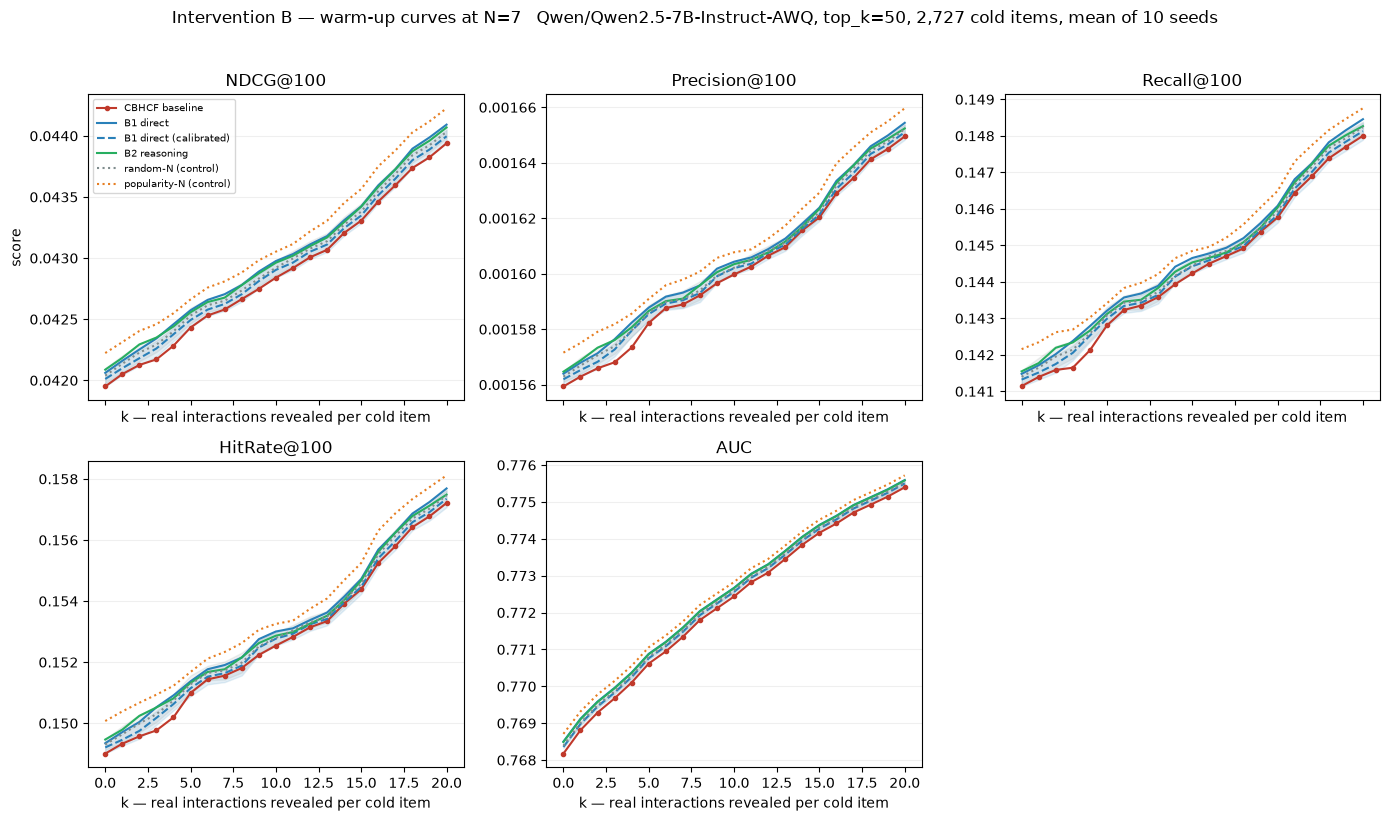

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex="col")
axes = axes.flatten()
STYLE = {
    "direct": dict(color="#2980b9", ls="-", label="B1 direct"),
    "direct_cal": dict(color="#2980b9", ls="--", label="B1 direct (calibrated)"),
    "reasoning": dict(color="#27ae60", ls="-", label="B2 reasoning"),
    "reasoning_cal": dict(color="#27ae60", ls="--", label="B2 reasoning (calibrated)"),
    "direct_floor": dict(color="#8e44ad", ls="-.", label="B1 direct (abstaining)"),
    "reasoning_floor": dict(color="#16a085", ls="-.", label="B2 reasoning (abstaining)"),
    "random": dict(color="#7f8c8d", ls=":", label="random-N (control)"),
    "random_matched": dict(color="#34495e", ls=":", label="random matched (control)"),
    "popularity": dict(color="#e67e22", ls=":", label="popularity-N (control)"),
}
for j, (ax, metric) in enumerate(zip(axes, METRICS)):
    show = (lambda t: t) if j == 0 else (lambda t: None)
    ax.plot(K_LEVELS, cbhcf_curve[metric]["mean"], color="#c0392b", lw=1.5, marker="o",
            markersize=3, label=show("CBHCF baseline"))
    for arm in ARM_ORDER:
        st = STYLE[arm]
        mean = np.array(curves[arm][metric]["mean"])
        ax.plot(K_LEVELS, mean, color=st["color"], ls=st["ls"], lw=1.5, label=show(st["label"]))
        if arm in ("direct_cal", "random"):
            sd = np.array(curves[arm][metric]["std"])
            ax.fill_between(K_LEVELS, mean - sd, mean + sd, color=st["color"], alpha=0.12)
    ax.set_title("AUC" if metric == "AUC" else f"{metric}@{K}")
    ax.set_xlabel("k — real interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)
for ax in axes[len(METRICS):]:
    ax.set_visible(False)
axes[0].set_ylabel("score")
axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle(f"Intervention B — warm-up curves at N={N_SELECT}   {COLDLLM_MODEL}, "
             f"top_k={COLDLLM_TOP_K}, {len(coldllm_cold_items):,} cold items, "
             f"mean of {N_SEEDS} seeds", y=1.02)
plt.tight_layout()
plt.savefig("warmup_curve_intervention_b.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Persist results

In [26]:
%%time
import datetime

results = {
    "config": {
        "ALS_PARAMS": ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K, "K_LEVELS": K_LEVELS,
        "COLDLLM_MODEL": COLDLLM_MODEL, "COLDLLM_TOP_K": COLDLLM_TOP_K,
        "N_SELECT": N_SELECT,
        "N_SELECT_provenance": "median item degree in ref_train; a priori, NOT tuned on any result",
        "warm_item_degree_median": float(np.median(_warm_degree)),
        "warm_item_degree_mean": float(_warm_degree.mean()),
        "N_GRID": N_GRID, "N_SENS_SEEDS": N_SENS_SEEDS,
        "STRATEGIES": STRATEGIES, "ARM_ORDER": ARM_ORDER,
        "PROMPT_ROLES": list(PROMPT_ROLES), "MAX_HISTORY": MAX_HISTORY, "PROMPT_TAG": PROMPT_TAG,
        "N_PROBE": int(N_PROBE), "PROBE_ITEMS": [int(i) for i in PROBE_ITEMS],
        "CALIBRATE_STRATEGIES": CALIBRATE_STRATEGIES,
        "PRIOR_COVERAGE": PRIOR_COVERAGE, "CALIBRATED_OK": CALIBRATED_OK,
        "PRIOR_STATS": PRIOR_STATS,
        "INCLUDE_FLOOR_ARM": INCLUDE_FLOOR_ARM,
        "FLOOR_ARM_THRESHOLD": FLOOR_ARM_THRESHOLD,
        "frac_items_forced_past_endorsement": _forced,
        "CONTROL_FOR": CONTROL_FOR,
        "quantization_parity": {   # bench_27, 1,000 pairs scored under both builds
            "reference_model": "Qwen/Qwen2.5-7B-Instruct",
            "within_item_spearman_mean": 0.779,
            "top7_jaccard": 0.501, "chance_jaccard": 0.163,
        },
        "RUN_KEYS": RUN_KEYS, "PRIOR_KEYS": PRIOR_KEYS,
        "CBHCF_FIELD_WEIGHTS": CBHCF_FIELD_WEIGHTS, "CBHCF_LAMBDA": CBHCF_LAMBDA,
        "SUBSAMPLE_N_COLD": SUBSAMPLE_N_COLD,
        "n_cold_items": int(len(coldllm_cold_items)), "n_candidate_pairs": int(n_pairs),
        "n_distinct_candidate_users": int(len(candidate_users)),
        "refine_stats": refine_stats,
        "arm_nnz": {k: int(v.nnz) for k, v in _arms0.items()},
        "dataset_fingerprint": list(FP),
        # Was the path of a steel-thread baseline_cf_*.pkl. The baseline is now the `"none"` arm
        # computed in this run, so the provenance is this file's own config -- same seeds, same
        # content block, same sweep as every arm it is compared against.
        "cbhcf_baseline_source": f"in-notebook zero-synthetic arm, {N_SEEDS} seeds",
        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
    },
    "cold_start_k0": {
        "cbhcf_baseline": {m: float(cbhcf_curve[m]["mean"][0]) for m in METRICS},
        **{arm: {m: float(curves[arm][m]["mean"][0]) for m in METRICS} for arm in ARM_ORDER},
    },
    "warm_up_curve": {"cbhcf_baseline": cbhcf_curve, "k_levels": K_LEVELS,
                      **{arm: curves[arm] for arm in ARM_ORDER}},
    # Section 7b: the same arms with the content half removed. Saved because it is what
    # distinguishes "the LLM's ordering carries nothing" from "CBHCF's content weighting hides
    # it" -- and section 8 alone cannot tell those apart.
    "als_only": {arm: als_curves[arm] for arm in ARM_ORDER},
    # 7c: synthetic data at fold-in ONLY, over the steel thread's own unaugmented
    # seeds -- user factors identical across every arm and the baseline.
    "foldin_only": {arm: foldin_curves[arm] for arm in ARM_ORDER},
    "foldin_only_seed_k0": {arm: np.asarray(foldin_seeds[arm]).tolist()
                            for arm in ARM_ORDER},
    "als_only_no_synthetic": _als_base,
    "n_sensitivity": {f"{arm}@{n}": {m: float(c[m]["mean"][0]) for m in METRICS}
                      for (arm, n), c in sens.items()},
}

os.makedirs("../outputs", exist_ok=True)
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
base = f"../outputs/intervention_b_coldllm_{stamp}"
with open(base + ".pkl", "wb") as f:
    pickle.dump(results, f)
def _jsonable(o):
    """`float(o) if hasattr(o, "__float__")` looks right and is not: a numpy ARRAY has __float__
    but raises for size > 1, and every warm-up curve here is an array. Arrays are converted
    element-wise; scalars are narrowed; anything else falls back to its string form."""
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if hasattr(o, "tolist"):
        return o.tolist()
    return str(o)


with open(base + ".json", "w") as f:
    json.dump(results, f, indent=2, default=_jsonable)
print(f"Saved results to {base}.pkl and {base}.json")

Saved results to ../outputs/intervention_b_coldllm_20260809_133813.pkl and ../outputs/intervention_b_coldllm_20260809_133813.json
CPU times: user 5.41 ms, sys: 2.03 ms, total: 7.44 ms
Wall time: 7.23 ms


### 9b. Hand the synthetic matrices to `steel_thread.ipynb`

The steel thread compares every method on one figure, and Intervention B belongs there — but
only in its **fold-in-only** form (§7c). The in-fit form would give that notebook's arms
different user factors, breaking the one invariant the whole comparison rests on.

Only the matrices cross over, keyed on the dataset fingerprint. `steel_thread.ipynb` then needs
no LLM, no vLLM and no GPU inference: it wraps its **existing** CBHCF models in
`SyntheticAugmentedDataset` and runs one more sweep. `random` is exported alongside the LLM arms
on purpose — without its control curve in the same figure, a reader sees Intervention B sitting
slightly above CBHCF and concludes the LLM did it, when a random draw from the same pool lands
in almost the same place.

In [27]:
# The random control is redrawn PER SEED and all N_SEEDS draws are exported. A single draw would
# make the control curve one sample's idiosyncrasy, and its band would carry only model noise while
# the quantity it controls for -- which users were picked -- was held artificially fixed. Averaging
# ten draws puts the same statistical weight behind the control as behind the arm it judges.
# Deterministic arms need only one matrix; `build_arms` ignores `seed` for them.
_SEED_DEPENDENT = {"random", "random_matched"}
_ib_key = hashlib.md5(repr((FP, "coldllm_synthetic", N_SELECT)).encode()).hexdigest()[:10]
_ib_path = f"../data/cache/coldllm_synthetic_{_ib_key}.pkl"
_seed_mats = {arm: [build_arms(N_SELECT, seed=s)[arm] for s in range(N_SEEDS)]
              for arm in ARM_ORDER if arm in _SEED_DEPENDENT}
with open(_ib_path, "wb") as f:
    pickle.dump({
        "matrices": {arm: _arms0[arm] for arm in ARM_ORDER},
        "seed_matrices": _seed_mats,          # one per seed, for the arms where the draw varies
        "n_seeds": N_SEEDS,
        "dataset_fingerprint": list(FP),
        "N_SELECT": N_SELECT, "COLDLLM_TOP_K": COLDLLM_TOP_K, "COLDLLM_MODEL": COLDLLM_MODEL,
        "PROMPT_TAG": PROMPT_TAG, "ARM_ORDER": ARM_ORDER, "CONTROL_FOR": CONTROL_FOR,
        "n_cold_items": int(len(coldllm_cold_items)),
        "results_source": base + ".pkl",
        "usage": "fold-in only; do NOT add these to any fit()",
    }, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Exported {len(ARM_ORDER)} synthetic matrices for steel_thread.ipynb -> {_ib_path}")
print(f"  arms: {ARM_ORDER}")
print(f"  each injects {_arms0[ARM_ORDER[0]].nnz:,} interactions over "
      f"{len(coldllm_cold_items):,} cold items at N={N_SELECT}")
for _a, _ms in _seed_mats.items():
    print(f"  {_a}: {len(_ms)} independent draws "
          f"(nnz {_ms[0].nnz:,}; overlap between draws 0 and 1: "
          f"{len(set(zip(*_ms[0].nonzero())) & set(zip(*_ms[1].nonzero()))):,})")

Exported 5 synthetic matrices for steel_thread.ipynb -> ../data/cache/coldllm_synthetic_41bd130ab1.pkl
  arms: ['direct', 'direct_cal', 'reasoning', 'random', 'popularity']
  each injects 19,089 interactions over 2,727 cold items at N=7
  random: 10 independent draws (nnz 19,089; overlap between draws 0 and 1: 2,675)


In [28]:
if WANDB_ENABLED:
    for arm in ARM_ORDER:
        run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME,
                         name=f"intervention-b-{arm}-{RUN_TAG}", mode=WANDB_MODE,
                         config={**ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K, "arm": arm,
                                 "N_SELECT": N_SELECT, "model": COLDLLM_MODEL,
                                 "top_k": COLDLLM_TOP_K, "prompt_tag": PROMPT_TAG},
                         reinit="create_new")
        for j, k in enumerate(K_LEVELS):
            run.log({"k": k, **{m: curves[arm][m]["mean"][j] for m in METRICS}})
        run.finish()
    print("Logged every arm to W&B.")
else:
    print("W&B disabled (WANDB_ENABLED = False) -- nothing uploaded.")

W&B disabled (WANDB_ENABLED = False) -- nothing uploaded.


## 10. Summary

- **Objective.** Test whether ColdLLM-style synthetic interactions give a strict cold-start item
  something to learn from *before* it has a single real interaction — the gap `steel_thread.ipynb`
  shows ALS's fold-in cannot close at `k=0`. Measured as CBHCF + ColdLLM against CBHCF itself,
  both arms sharing one content representation, one lambda, one frozen user profile and one seed
  protocol.
- **The decisive comparison is against `random-N`, not the baseline.** All six arms draw from the
  same Filtering pool and inject the same number of interactions per item, so a gap between them
  is attributable to *which* users were chosen and nothing else. If the LLM arms do not beat a
  random draw from that pool, content similarity did the work.
- **Zero-shot means ranking, not probability.** The judge would answer "yes" to ~98% of
  candidates, so the pipeline stores graded log-odds and ranks on them rather than thresholding.
  The scores are persisted per pair, which is why `N`, calibration and every ablation above are
  offline array operations rather than another 3-hour run of the model.
- **Calibration.** The per-user prior is the only correction that can reorder a per-item ranking
  (`bench_25` proves a global one cannot). §5f reports how much of the score variance it actually
  explains, and the raw/calibrated arm pairs show whether it changed the answer.
### Extensions deliberately not run here

Both are selection rules over the stored scores, so both cost ALS fits and **no GPU** — they were
left out on design grounds, not budget.

- **Uncapped abstention.** The floor arm above is `min(N, endorsed)`: it can give fewer than `N`,
  never more. The literal reading of ColdLLM — every endorsed pair becomes an interaction — would
  instead give most items 40–50, since ~98% of candidates are endorsed. That puts every cold item
  in the top 2% of the real degree distribution, which is the off-distribution problem that
  anchored `N` to the median in the first place, and it varies volume so wildly that an arm would
  differ from its control in both *who* was chosen and *how many*. It also answers a different
  question — "does more synthetic data help?" — which the `N=50` point of the sensitivity sweep
  already speaks to.

- **Confidence weighting.** ALS reads its input as confidence (`c_ui = 1 + alpha*r_ui`), so
  synthetic pairs could carry a weight from their score rather than being binarised — strong
  endorsements pulling harder, weak ones barely, and hopeless items naturally contributing almost
  nothing. It is the most elegant use of a graded score, and the objection is not the mechanics
  (a control matched on total weight is perfectly constructible): it is that weighting consumes
  the **magnitudes**, and this whole design rests on the magnitudes being untrustworthy while the
  ordering is not. Top-N is invariant to any monotone recalibration; a weight is not, so
  rewording the prompt would move every one. Weighting by **rank** rather than score
  (`w = 1 - rank/N`) is the monotone-safe version and the better form of this extension. A
  secondary cost: every other arm in this project is binary implicit feedback, so weighting one
  of them weakens the hold-everything-else-fixed principle the steel thread is built on.

- **Quantization is a real choice, not a free one.** The model is the 4-bit AWQ build, because
  it leaves ~14 GB of the card for KV cache against bf16's ~4.9 GB — roughly 3x the concurrency,
  and the difference between a ~5.6 h pair pass and a ~17 h one. `bench_27` measures what that
  costs by scoring 1,000 identical pairs under both builds: within-item Spearman **+0.78**
  (median +0.81) and top-7 agreement **Jaccard 0.50**, against a chance floor of 0.16. So the
  ordering is substantially preserved and is nowhere near random — but roughly **one in three
  selected users differs** between the two builds, and bf16 is only the unquantized reference,
  not ground truth, so where they disagree neither can be called correct. The synthetic
  interactions here are therefore quantization-dependent. The study's conclusion is not: it
  rests on LLM-vs-`random`, and both builds sit far above chance relative to a random draw.

- **Honest limits.** `N` is fixed a priori rather than selected on `cold_val`, because scoring
  `cold_val` with the LLM would double the GPU cost; the N-sensitivity curve is a robustness
  check, not a selection. B1 and B2 log-odds *levels* are not comparable to each other (B2's
  answer is conditioned on its own generated reasoning) — only their rankings are. And Filtering
  uses the same content space CBHCF scores with, so a cold item whose text is uninformative is
  poorly served at both stages; this intervention can only help where content already carries
  signal.